# CatBoost classifier training notebook

This notebook trains a CatBoost classifier for `p_Truth_isElectron`. It first loads the data, optionally performs SHAP-based feature selection, tunes CatBoost hyperparameters, retrains the final model with early stopping, evaluates it, and saves the model artifacts.

## 1. Imports

Load the Python packages used for data handling, CatBoost training, hyperparameter search, metrics, and plotting.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from catboost import (
    CatBoostClassifier,
    Pool,
    EFeaturesSelectionAlgorithm,
    EShapCalcType,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    log_loss,
    auc,
)
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, train_test_split

import seaborn as sns
import matplotlib.pyplot as plt

## 2. Configuration and data split

Set project paths, define the target column, load the training data, and create reproducible train/validation/test splits. The validation split is used for feature selection and early stopping; the test split is kept for final local evaluation.

In [2]:
# ============================================================ CONFIG
PROJECT_ROOT = Path("/Users/prometheus/Documents/Python/Electron_Project")
DATA_DIR     = PROJECT_ROOT / "Data"
SAVED_DIR    = PROJECT_ROOT / "Classification" / "CatBoost_classifier" / "saved_models"
SUBMIT_DIR   = PROJECT_ROOT / "Submission"
INPUT_DIR    = PROJECT_ROOT / "Input_lists"

TRAIN_H5 = DATA_DIR / "AppML_InitialProject_train.h5"
TEST_H5  = DATA_DIR / "AppML_InitialProject_test_classification.h5"

TARGET_COL   = "p_Truth_isElectron"
SUBMITTER    = "RasmusReimer"
MODEL_NAME   = "CatBoost_Classifier"

TEST_SIZE    = 0.20
VAL_SIZE     = 0.10
RANDOM_STATE = 42

CATEGORICAL_FEATURE_CANDIDATES = [
    "pX_ambiguityType",
    "pX_author",
    "pX_OQ",
    "pX_maxEcell_gain",
]

# Load data once and define the full candidate feature matrix.
df = pd.read_hdf(TRAIN_H5)

y = df[TARGET_COL].astype(int)
X = df.drop(columns=["p_Truth_isElectron", "p_Truth_Energy"])

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

val_frac = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_frac,
    random_state=RANDOM_STATE,
    stratify=y_trainval,
)

cat_features = [c for c in CATEGORICAL_FEATURE_CANDIDATES if c in X.columns]

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

print(f"Full feature count: {X.shape[1]}")
print(f"Train rows: {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Test rows: {len(X_test)}")
print(f"Categorical features: {cat_features}")

Full feature count: 140
Train rows: 126000
Validation rows: 18000
Test rows: 36000
Categorical features: ['pX_ambiguityType', 'pX_author', 'pX_OQ', 'pX_maxEcell_gain']


## 3. SHAP-based feature selection

CatBoost recursively removes weak features using SHAP values and keeps the selected feature names in `selected_features`. The next cell uses this list for tuning and final training.

In [3]:
# CatBoost SHAP-based recursive feature selection.
# The final selected feature list is reused in the tuning cell below.
selector_model = CatBoostClassifier(
    iterations=4000,
    learning_rate=0.03,
    depth=5,
    l2_leaf_reg=5,
    loss_function="Logloss",
    eval_metric="Logloss",
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE,
    od_type="Iter",
    od_wait=150,
    verbose=200,
)

summary = selector_model.select_features(
    train_pool,
    eval_set=val_pool,
    features_for_select=list(X.columns),
    num_features_to_select=15,
    steps=8,
    algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
    shap_calc_type=EShapCalcType.Regular,
    train_final_model=True,
    logging_level="Verbose",
    plot=True,
)

selected_features = summary["selected_features_names"]
selected_features

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Step #1 out of 8
0:	learn: 0.6482343	test: 0.6478429	best: 0.6478429 (0)	total: 87.9ms	remaining: 5m 51s
200:	learn: 0.1125985	test: 0.1110324	best: 0.1110324 (200)	total: 4.64s	remaining: 1m 27s
400:	learn: 0.0969111	test: 0.0979191	best: 0.0979191 (400)	total: 9.14s	remaining: 1m 22s
600:	learn: 0.0878694	test: 0.0918635	best: 0.0918635 (600)	total: 13.8s	remaining: 1m 17s
800:	learn: 0.0814757	test: 0.0888701	best: 0.0888701 (800)	total: 18.4s	remaining: 1m 13s
1000:	learn: 0.0765622	test: 0.0870609	best: 0.0870609 (1000)	total: 23.3s	remaining: 1m 9s
1200:	learn: 0.0725788	test: 0.0858706	best: 0.0858706 (1200)	total: 28s	remaining: 1m 5s
1400:	learn: 0.0691392	test: 0.0849857	best: 0.0849789 (1399)	total: 32.7s	remaining: 1m
1600:	learn: 0.0660678	test: 0.0842817	best: 0.0842759 (1590)	total: 37.5s	remaining: 56.1s
1800:	learn: 0.0631576	test: 0.0837773	best: 0.0837698 (1799)	total: 42.5s	remaining: 51.9s
2000:	learn: 0.0604938	test: 0.0833053	best: 0.0832918 (1996)	total: 47.6s	r

['p_Rhad',
 'p_TRTPID',
 'p_numberOfInnermostPixelHits',
 'p_d0',
 'p_sigmad0',
 'p_dPOverP',
 'p_deltaEta1',
 'p_etcone20',
 'p_ptcone40',
 'p_ptPU30',
 'pX_MultiLepton',
 'pX_ambiguityType',
 'pX_E3x5_Lr1',
 'p_pt_track',
 'p_charge']

## 4. Hyperparameter tuning and final training

This is the fixed version of the original tuning cell. Two CatBoost/sklearn issues are avoided here:

1. `od_type` and `od_wait` are not used inside `RandomizedSearchCV`, because early stopping needs an explicit validation set for every CV fold.
2. `cat_features` is not passed in the constructor of the estimator used by `RandomizedSearchCV`. Some CatBoost versions mutate this parameter internally, which prevents sklearn from cloning the estimator. Instead, categorical feature indices are passed to `rscv.fit(...)`.

After the CV search, the final CatBoost model is retrained on the train split with early stopping against the validation split.


In [4]:
# ============================================================ TUNE + FINAL TRAIN
# This cell expects `selected_features` from the previous cell.
# If you want to skip feature selection, uncomment the fallback line below.

# selected_features = list(X.columns)

FEATURES = list(selected_features)
TARGET = TARGET_COL

# Rebuild X using only the selected features.
X_selected = df[FEATURES].copy()
y = df[TARGET].astype(int)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_selected,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

val_frac = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_frac,
    random_state=RANDOM_STATE,
    stratify=y_trainval,
)

cat_features = [c for c in CATEGORICAL_FEATURE_CANDIDATES if c in X_selected.columns]
cat_feature_indices = [X_selected.columns.get_loc(c) for c in cat_features]

print(f"Selected feature count: {len(FEATURES)}")
print(f"Categorical features used by final model: {cat_features}")
print(f"Categorical feature indices: {cat_feature_indices}")

param_dist = {
    "iterations": [500, 1000, 2000],
    "learning_rate": uniform(0.01, 0.09),       # 0.01 to 0.10
    "depth": randint(4, 9),                    # 4 to 8
    "l2_leaf_reg": uniform(1, 9),              # 1 to 10
    "min_data_in_leaf": randint(5, 51),        # 5 to 50
    "bootstrap_type": ["Bernoulli"],
    "subsample": uniform(0.6, 0.4),            # 0.6 to 1.0, valid with Bernoulli bootstrap
}


base_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="Logloss",
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False,
)

rscv = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_log_loss",
    cv=3,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=1,          
    refit=True,
)

# Pass categorical feature indices as fit-time metadata, not as constructor state.
rscv.fit(X_trainval, y_trainval, cat_features=cat_feature_indices)

print("Best params:", rscv.best_params_)
print("Best CV log-loss:", -rscv.best_score_)

# Retrain the best model with early stopping on the held-out validation split.
best_params = rscv.best_params_.copy()
best_params["iterations"] = 5000

model = CatBoostClassifier(
    **best_params,
    loss_function="Logloss",
    eval_metric="Logloss",
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE,
    od_type="Iter",
    od_wait=150,
    verbose=200,
    allow_writing_files=False,
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

model.fit(train_pool, eval_set=val_pool, use_best_model=True)


Selected feature count: 15
Categorical features used by final model: ['pX_ambiguityType']
Categorical feature indices: [11]
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END bootstrap_type=Bernoulli, depth=7, iterations=500, l2_leaf_reg=2.650913108795474, learning_rate=0.08017219002454923, min_data_in_leaf=25, subsample=0.6624074561769746; total time=   6.8s
[CV] END bootstrap_type=Bernoulli, depth=7, iterations=500, l2_leaf_reg=2.650913108795474, learning_rate=0.08017219002454923, min_data_in_leaf=25, subsample=0.6624074561769746; total time=   6.6s
[CV] END bootstrap_type=Bernoulli, depth=7, iterations=500, l2_leaf_reg=2.650913108795474, learning_rate=0.08017219002454923, min_data_in_leaf=25, subsample=0.6624074561769746; total time=   6.5s
[CV] END bootstrap_type=Bernoulli, depth=6, iterations=2000, l2_leaf_reg=1.5227525095137953, learning_rate=0.08795585311974416, min_data_in_leaf=40, subsample=0.6571467271687763; total time=  22.5s
[CV] END bootstrap_type=Berno

CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', bootstrap_type='Bernoulli', depth=6, eval_metric='Logloss', iterations=5000, l2_leaf_reg=np.float64(7.361716094628554), learning_rate=np.float64(0.07561064512368885), loss_function='Logloss', min_data_in_leaf=37, od_type='Iter', od_wait=150, random_seed=42, subsample=np.float64(0.8423839899124046), verbose=200)

## 5. Validation metrics

Check the log-loss and AUC on the validation split. This gives a quick sanity check before looking at the final local test split.

In [5]:
# Validation metrics are useful for checking whether tuning and early stopping behaved sensibly.
val_probs = model.predict_proba(X_val)[:, 1]

print("Val BCE/logloss:", log_loss(y_val, val_probs))
print("Val AUC:", roc_auc_score(y_val, val_probs))

Val BCE/logloss: 0.08972198794725823
Val AUC: 0.9944573556880167


## 6. Local test-set diagnostics

Evaluate probabilities using BCE/log-loss and AUC. The confusion matrix and F1 score use a fixed threshold of 0.5 only for diagnostics; the competition-style classification score is usually based on probabilities rather than hard labels.

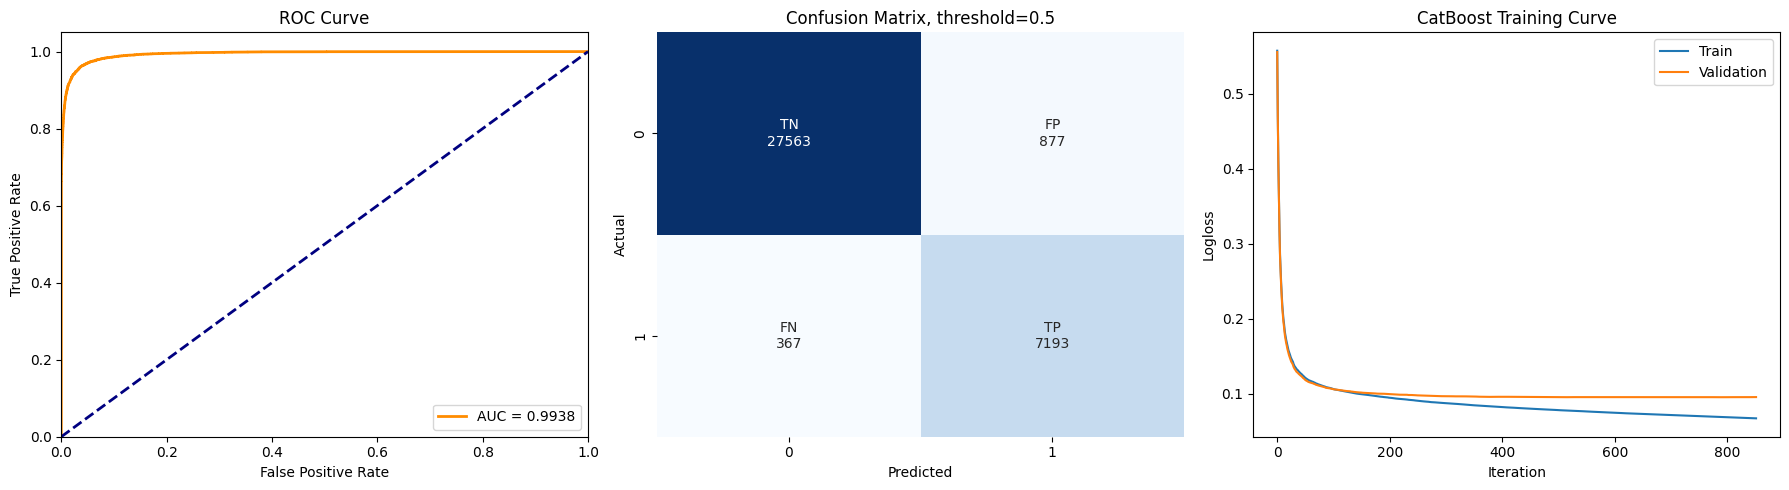

BCE / Logloss: 0.09030350500181726
AUC: 0.9937783526443864
F1 at threshold 0.5: 0.9204094689699296
[[27563   877]
 [  367  7193]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     28440
           1       0.89      0.95      0.92      7560

    accuracy                           0.97     36000
   macro avg       0.94      0.96      0.95     36000
weighted avg       0.97      0.97      0.97     36000



In [6]:
# Probabilities are what matter for BCE/logloss grading.
test_probs = model.predict_proba(X_test)[:, 1]

# Only for diagnostic plots/reports, not for final BCE score.
display_threshold = 0.5
test_pred = (test_probs >= display_threshold).astype(int)

fpr, tpr, _ = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(y_test, test_pred)

evals = model.get_evals_result()

# Robustly find CatBoost train/validation metric curves.
train_key = "learn"
val_key = next(k for k in evals.keys() if k != "learn")

metric_name = "Logloss" if "Logloss" in evals[train_key] else list(evals[train_key].keys())[0]
train_curve = evals[train_key][metric_name]
val_curve = evals[val_key][metric_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")

# Confusion matrix
cm_labels = np.array([["TN", "FP"], ["FN", "TP"]])
cm_annot = np.array([
    [f"{label}\n{value}" for label, value in zip(label_row, value_row)]
    for label_row, value_row in zip(cm_labels, cm)
])

sns.heatmap(cm, annot=cm_annot, fmt="", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title(f"Confusion Matrix, threshold={display_threshold}")

# CatBoost training curve
axes[2].plot(train_curve, label="Train")
axes[2].plot(val_curve, label="Validation")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel(metric_name)
axes[2].set_title("CatBoost Training Curve")
axes[2].legend()

plt.tight_layout()
plt.show()

print("BCE / Logloss:", log_loss(y_test, test_probs))
print("AUC:", roc_auc_score(y_test, test_probs))
print("F1 at threshold 0.5:", f1_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))


## 7. Save model artifacts

Save the final CatBoost model, metadata needed for reproducible inference, and the selected input feature list.

In [7]:
# Save the trained CatBoost model, model metadata, and selected feature list.
SAVED_DIR.mkdir(parents=True, exist_ok=True)
INPUT_DIR.mkdir(parents=True, exist_ok=True)

model.save_model(SAVED_DIR / "CatBoost_final.cbm")

with open(SAVED_DIR / "CatBoost_final_params.json", "w") as f:
    json.dump({
        "features": FEATURES,
        "categorical_features": cat_features,
        "categorical_feature_indices": cat_feature_indices,
        "best_iteration": model.get_best_iteration(),
        "model_params": model.get_all_params(),
    }, f, indent=2)

with open(INPUT_DIR / "CatBoost_input_features.txt", "w") as f:
    for feat in FEATURES:
        f.write(feat + "\n")

print(f"Saved model to: {SAVED_DIR / 'CatBoost_final.cbm'}")
print(f"Saved params to: {SAVED_DIR / 'CatBoost_final_params.json'}")
print(f"Saved feature list to: {INPUT_DIR / 'CatBoost_input_features.txt'}")


Saved model to: /Users/prometheus/Documents/Python/Electron_Project/Classification/CatBoost_classifier/saved_models/CatBoost_final.cbm
Saved params to: /Users/prometheus/Documents/Python/Electron_Project/Classification/CatBoost_classifier/saved_models/CatBoost_final_params.json
Saved feature list to: /Users/prometheus/Documents/Python/Electron_Project/Input_lists/CatBoost_input_features.txt


## 8. Inference and submission

Score the held-out classification test set with the trained model and write the submission pair (predictions + variable list) to the project `Submission/` folder. Files are headerless to match the SubmissionChecker format used by the other classifiers.

In [8]:
# ============================================================ INFERENCE & SUBMISSION
# Predict on the held-out classification test set and write the submission pair
# to Electron_Project/Submission, matching the format used by the NN/XGB classifiers.
SUBMIT_DIR.mkdir(parents=True, exist_ok=True)

test_df = pd.read_hdf(TEST_H5)
if TARGET_COL in test_df.columns:                  # held-out set should not have it
    test_df = test_df.drop(columns=[TARGET_COL])
print(f"Loaded test set: {test_df.shape[0]} rows, {test_df.shape[1]} columns")

X_submit = test_df[FEATURES].copy()
submit_probs = model.predict_proba(X_submit)[:, 1]
print(
    f"Predictions: range = [{submit_probs.min():.4f}, {submit_probs.max():.4f}],"
    f" mean = {submit_probs.mean():.4f}"
)

base = f"Classification_{SUBMITTER}_{MODEL_NAME}"
submission_path    = SUBMIT_DIR / f"{base}.csv"
variable_list_path = SUBMIT_DIR / f"{base}_VariableList.csv"

pd.DataFrame({"index": test_df.index, "p_isElectron": submit_probs}) \
    .to_csv(submission_path, index=False, header=False)

pd.Series(sorted(FEATURES)) \
    .to_csv(variable_list_path, index=False, header=False)

print(f"Wrote {submission_path}")
print(f"Wrote {variable_list_path}")


Loaded test set: 60000 rows, 140 columns
Predictions: range = [0.0000, 1.0000], mean = 0.2369
Wrote /Users/prometheus/Documents/Python/Electron_Project/Submission/Classification_RasmusReimer_CatBoost_Classifier.csv
Wrote /Users/prometheus/Documents/Python/Electron_Project/Submission/Classification_RasmusReimer_CatBoost_Classifier_VariableList.csv
